# LLAT polar — 訓練分析

| | baseline(學姊) | mine(本次) |
|---|---|---|
| 變數 | u / v | **vt / vr** |
| 網格 | R=201(Δr 0.05°) | **R=41(Δr 0.25°)** |
| 精度 | fp32 | **bf16-mixed** |
| 等效批次 | 4 | **32(8×H200)** |
| max_steps | 1,600,000(只跑 15.8%) | **105,000(跑滿)** |
| 峰值 LR | 4e-4 | 4e-4 |
| 牆鐘 | 8.32 天 | **6.7 小時** |

⚠️ **val_loss 不可直接比較** —— 變數表與網格不同,loss 的尺度與平均對象不一樣。
可直接比較的是:**LR 是否完成退火、訓練穩定性、吞吐**。

In [1]:
import csv, numpy as np, matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": .3})
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


def load(path):
    out = {}
    with open(path, newline="") as f:
        rd = csv.DictReader(f)
        for c in rd.fieldnames:
            out[c] = []
        for r in rd:
            for c in rd.fieldnames:
                v = r[c]
                out[c].append(float(v) if v not in ("", None) else np.nan)
    return {c: np.array(v) for c, v in out.items()}


def ser(d, col):
    """回傳該欄非 NaN 的 (step, value)"""
    m = ~np.isnan(d[col])
    return d["step"][m], d[col][m]


mine = load("run_mine_curves.csv")
base = load("run_baseline_curves.csv")

for n, d in (("mine", mine), ("baseline", base)):
    s, v = ser(d, "val_loss")
    print(f"{n:9s} val_loss {len(v):5d} 點  首 {v[0]:.5f}  末 {v[-1]:.5f}  "
          f"最佳 {v.min():.5f} @ step {int(s[v.argmin()])}")

mine      val_loss   231 點  首 0.35849  末 0.33168  最佳 0.30065 @ step 2269
baseline  val_loss    70 點  首 0.32564  末 0.29284  最佳 0.29061 @ step 239645


## 圖 1:損失曲線(對數座標才看得到 spike)

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

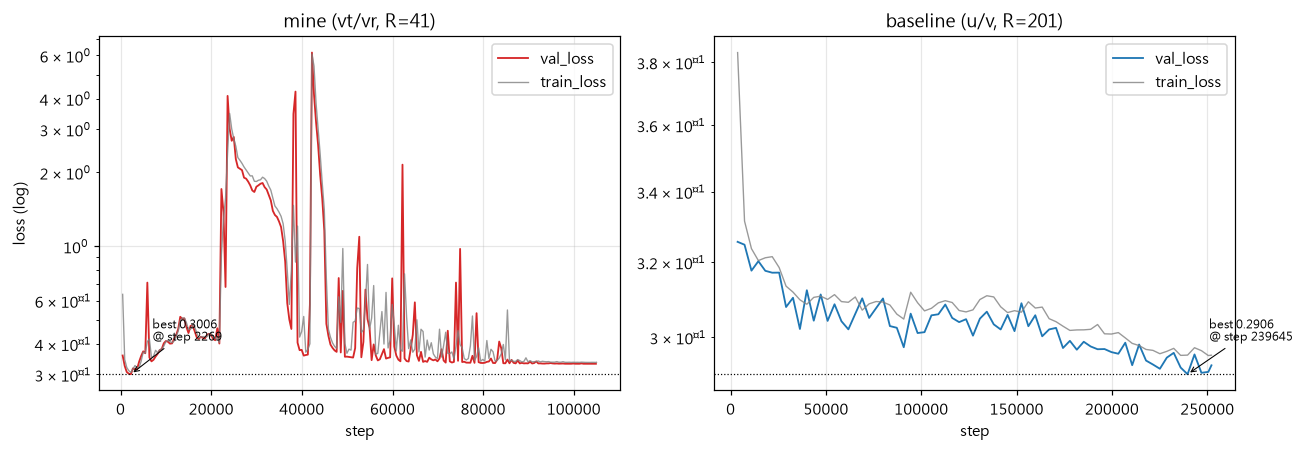

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

for i, (n, d, c) in enumerate([("mine (vt/vr, R=41)", mine, "tab:red"),
                               ("baseline (u/v, R=201)", base, "tab:blue")]):
    s, v = ser(d, "val_loss")
    st, vt = ser(d, "train_loss_epoch")
    ax[i].semilogy(s, v, c=c, lw=1.2, label="val_loss")
    ax[i].semilogy(st, vt, c="gray", lw=.9, alpha=.8, label="train_loss")
    ax[i].axhline(v.min(), ls=":", c="k", lw=.8)
    ax[i].annotate("best %.4f\n@ step %d" % (v.min(), s[v.argmin()]),
                   (s[v.argmin()], v.min()), textcoords="offset points",
                   xytext=(14, 22), fontsize=8,
                   arrowprops=dict(arrowstyle="->", lw=.7))
    ax[i].set_title(n)
    ax[i].set_xlabel("step")
    ax[i].legend()

ax[0].set_ylabel("loss (log)")
plt.tight_layout()
plt.show()

## 圖 2:學習率退火對照 —— **最關鍵的一張**

baseline 把 `max_steps` 設 1.6M 卻只跑到 252k(15.8%),cosine 只走了開頭一小段,
**結束時 LR 仍在峰值的 94%**;本次把 `max_steps` 設成跑得完的值,退火完整走到 0。

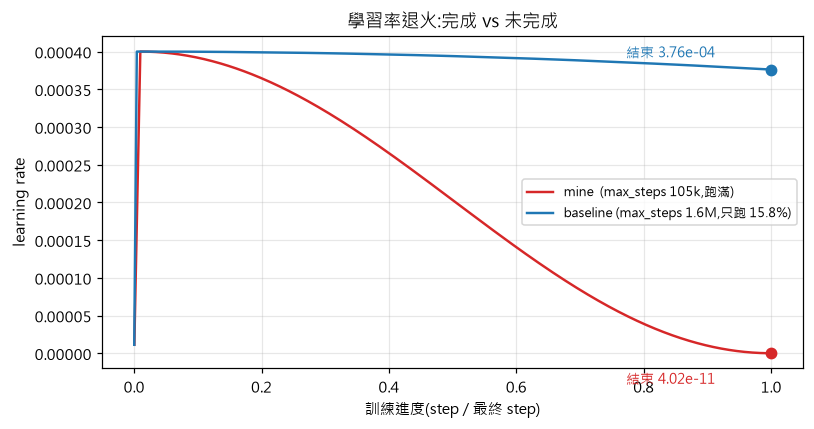

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4))

for n, d, c, dy in [("mine  (max_steps 105k,跑滿)", mine, "tab:red", -20),
                    ("baseline (max_steps 1.6M,只跑 15.8%)", base, "tab:blue", 8)]:
    s, v = ser(d, "lr-AdamW")
    ax.plot(s / s.max(), v, c=c, lw=1.6, label=n)
    ax.scatter([1.0], [v[-1]], c=c, s=45, zorder=5)
    ax.annotate("結束 %.2e" % v[-1], (1.0, v[-1]), textcoords="offset points",
                xytext=(-95, dy), fontsize=9, color=c)

ax.set_xlabel("訓練進度(step / 最終 step)")
ax.set_ylabel("learning rate")
ax.set_title("學習率退火:完成 vs 未完成")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

## 圖 3:LR 與訓練穩定性

把本次每個驗證點的 val_loss 對「當時的 LR」作圖 —— spike 隨 LR 下降而消失,
可讀出經驗穩定閾值,作為下一次實驗設定峰值 LR 的依據。

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

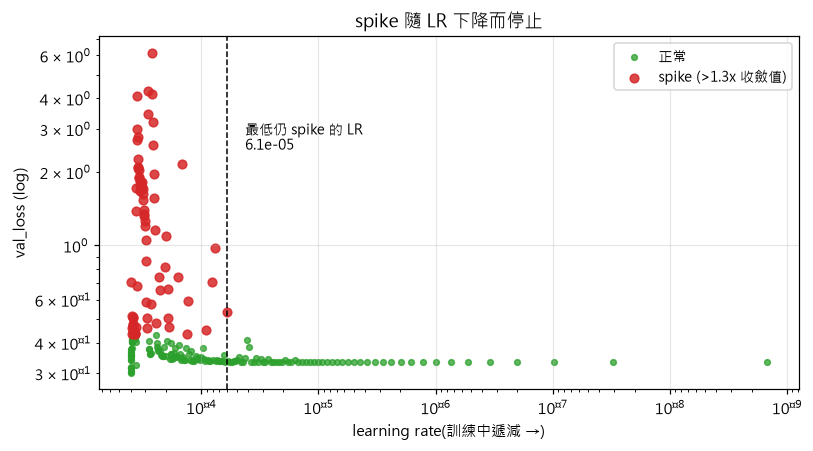

收斂水準            : 0.33211
spike 次數          : 76 / 231
最低仍 spike 的 LR  : 6.06e-05
→ 下次峰值 LR 建議 <= 6e-05


In [4]:
sv, v = ser(mine, "val_loss")
sl, l = ser(mine, "lr-AdamW")
lr_at = np.interp(sv, sl, l)          # 每個驗證點當時的 LR

lvl = np.median(v[-30:])              # 收斂後的水準
spike = v > lvl * 1.3

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.scatter(lr_at[~spike], v[~spike], s=14, c="tab:green", alpha=.75, label="正常")
ax.scatter(lr_at[spike], v[spike], s=32, c="tab:red", alpha=.85,
           label="spike (>1.3x 收斂值)")

if spike.any():
    thr = lr_at[spike].min()
    ax.axvline(thr, ls="--", c="k", lw=1)
    ax.annotate("最低仍 spike 的 LR\n%.1e" % thr, (thr, v.max() * .4),
                xytext=(12, 0), textcoords="offset points", fontsize=9)

ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel("learning rate(訓練中遞減 →)")
ax.set_ylabel("val_loss (log)")
ax.set_title("spike 隨 LR 下降而停止")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("收斂水準            : %.5f" % lvl)
print("spike 次數          : %d / %d" % (spike.sum(), len(v)))
if spike.any():
    print("最低仍 spike 的 LR  : %.2e" % lr_at[spike].min())
    print("→ 下次峰值 LR 建議 <= %.0e" % lr_at[spike].min())

## 圖 4:逐變數 val_RMSE

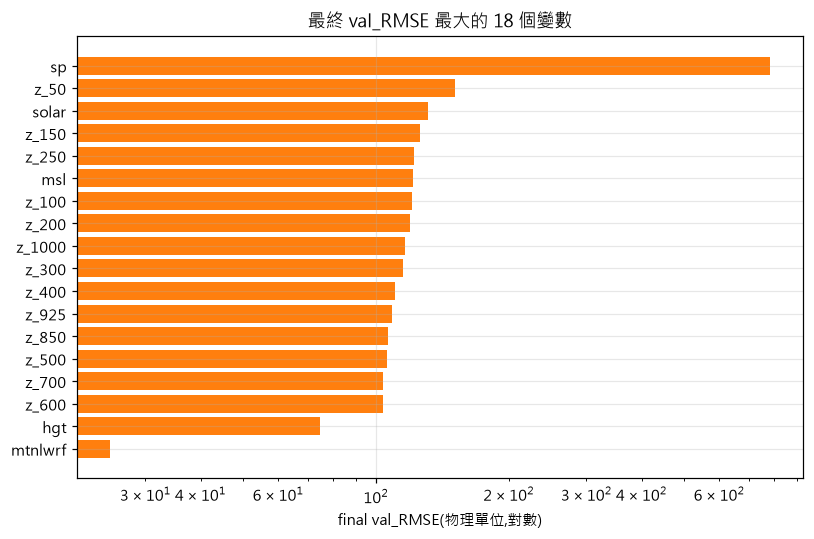

注意:各變數單位不同(Pa / m2s-2 / K ...),不可跨變數比大小。


In [5]:
per = {}
with open("run_mine_per_var.csv", newline="") as f:
    for r in csv.DictReader(f):
        per.setdefault(r["tag"], []).append((int(r["step"]), float(r["value"])))

final = {t: sorted(p)[-1][1] for t, p in per.items() if t.startswith("val_RMSE/")}
top = sorted(final.items(), key=lambda x: -x[1])[:18]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh([t.replace("val_RMSE/", "") for t, _ in top][::-1],
        [v for _, v in top][::-1], color="tab:orange")
ax.set_xscale("log")
ax.set_xlabel("final val_RMSE(物理單位,對數)")
ax.set_title("最終 val_RMSE 最大的 18 個變數")
plt.tight_layout()
plt.show()

print("注意:各變數單位不同(Pa / m2s-2 / K ...),不可跨變數比大小。")

## 摘要表(可貼進投影片)

In [6]:
def summ(d):
    s, v = ser(d, "val_loss")
    _, l = ser(d, "lr-AdamW")
    _, e = ser(d, "epoch")
    h = d["hours"][~np.isnan(d["hours"])]
    return dict(best=v.min(), bstep=int(s[v.argmin()]), final=v[-1],
                ep=int(e.max()), st=int(s.max()), lr0=l.max(), lr1=l[-1],
                hr=h.max() if len(h) else float("nan"))


a, b = summ(mine), summ(base)
rows = [
    ("最佳 val_loss", "%.5f (step %d)" % (a["best"], a["bstep"]),
                      "%.5f (step %d)" % (b["best"], b["bstep"])),
    ("最終 val_loss", "%.5f" % a["final"], "%.5f" % b["final"]),
    ("epochs", str(a["ep"]), str(b["ep"])),
    ("steps", "{:,}".format(a["st"]), "{:,}".format(b["st"])),
    ("牆鐘(小時)", "%.1f" % a["hr"], "%.1f" % b["hr"]),
    ("LR 峰值→結束", "%.1e → %.1e" % (a["lr0"], a["lr1"]),
                     "%.1e → %.1e" % (b["lr0"], b["lr1"])),
    ("LR 退火完成度", "%.0f%%" % ((1 - a["lr1"] / a["lr0"]) * 100),
                      "%.0f%%" % ((1 - b["lr1"] / b["lr0"]) * 100)),
]

w = max(len(r[0]) for r in rows)
print("%-*s  %26s  %26s" % (w, "", "mine (vt/vr, R=41)", "baseline (u/v, R=201)"))
print("-" * (w + 58))
for k, x, y in rows:
    print("%-*s  %26s  %26s" % (w, k, x, y))
print()
print("⚠️ val_loss 不可直接比較(變數表與網格不同)。")
print("   可比的是:LR 退火完成度、訓練穩定性、吞吐。")

                     mine (vt/vr, R=41)       baseline (u/v, R=201)
---------------------------------------------------------------------
最佳 val_loss         0.30065 (step 2269)       0.29061 (step 239645)
最終 val_loss                     0.33168                     0.29284
epochs                              231                          69
steps                           104,873                     252,160
牆鐘(小時)                              6.7                       199.6
LR 峰值→結束              4.0e-04 → 4.0e-11           4.0e-04 → 3.8e-04
LR 退火完成度                           100%                          6%

⚠️ val_loss 不可直接比較(變數表與網格不同)。
   可比的是:LR 退火完成度、訓練穩定性、吞吐。
